In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("../data/Dataset_Feature_Engineered.csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Restaurant_Name_Length,Address_Length,Table_Booking,Online_Delivery
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,3,4.8,Dark Green,Excellent,314,16,71,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,3,4.5,Dark Green,Excellent,591,16,67,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,4,4.4,Green,Very Good,270,22,56,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,4,4.9,Dark Green,Excellent,365,4,70,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,4,4.8,Dark Green,Excellent,229,11,64,1,0


In [4]:
features = [

    "Average Cost for two",

    "Price range",

    "Votes",

    "Table_Booking",

    "Online_Delivery",

    "Restaurant_Name_Length",

    "Address_Length"

]

In [5]:
target = "Aggregate rating"

In [6]:
X = df[features]

y = df[target]

In [7]:
print(X.isnull().sum())

Average Cost for two      0
Price range               0
Votes                     0
Table_Booking             0
Online_Delivery           0
Restaurant_Name_Length    0
Address_Length            0
dtype: int64


In [8]:
X = X.fillna(0)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (7640, 7)
Testing Shape : (1911, 7)


In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
lr_pred = lr.predict(X_test)

In [12]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("MSE :", mean_squared_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 1.075355566000077
MSE : 1.677532111748515
RMSE : 1.295195781242556
R2 Score : 0.2629825202173557


In [13]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [14]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, dt_pred))

print("MSE :", mean_squared_error(y_test, dt_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 0.3067503924646782
MSE : 0.2161250654107797
RMSE : 0.4648925310335494
R2 Score : 0.905046258184063


In [15]:
rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [16]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("MSE :", mean_squared_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest
MAE : 0.21720963282748992
MSE : 0.1110100476858029
RMSE : 0.3331817037080561
R2 Score : 0.9512281493731507


In [17]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "R2 Score":[

        r2_score(y_test, lr_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred)

    ]

})

results

,Model,R2 Score
0,Linear Regression,0.262983
1,Decision Tree,0.905046
2,Random Forest,0.951228


C:\Users\asus\AppData\Local\Temp\ipykernel_14676\2957139668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


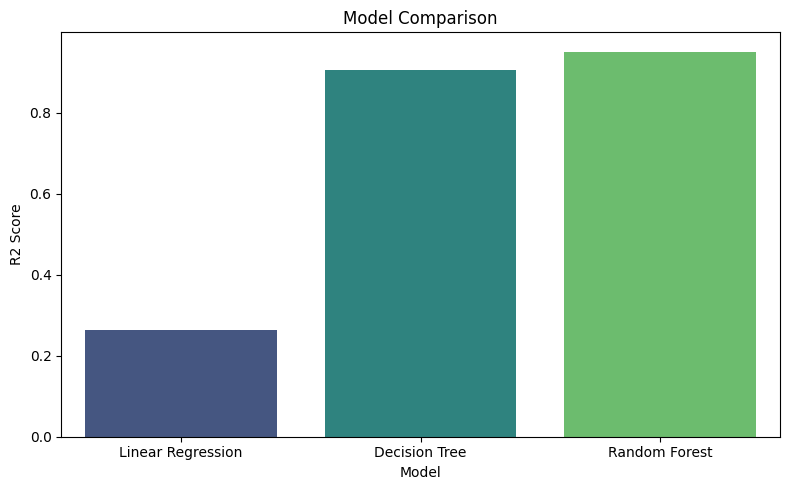

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score",
    palette="viridis"
)

plt.title("Model Comparison")

plt.tight_layout()

plt.savefig("../images/model_comparison.png", dpi=300)

plt.show()

In [19]:
best = results.loc[
    results["R2 Score"].idxmax()
]

print(best)

Model       Random Forest
R2 Score         0.951228
Name: 2, dtype: object
